In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

 **Task 6.1**

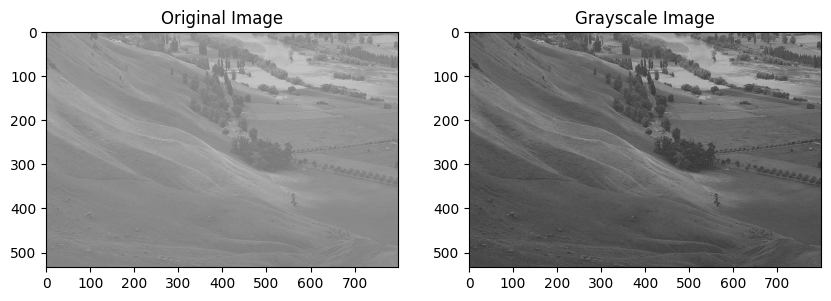

Image Matrix (partial):
[[125 149 160 155 134]
 [181 150 130 123 148]
 [155 141 150 132 142]
 [135 133 152 140 139]
 [146 144 145 137 123]]
Resolution: (534, 800)
Data Type: uint8


In [5]:
img = cv2.imread('hawkes_bay_in.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Image')
plt.show()

print('Image Matrix (partial):')
print(gray[0:5, 0:5])

print('Resolution:', gray.shape)
print('Data Type:', gray.dtype)

In [4]:
from google.colab import files
uploaded = files.upload()


Saving hawkes_bay_in.jpg to hawkes_bay_in.jpg


**Task:02**

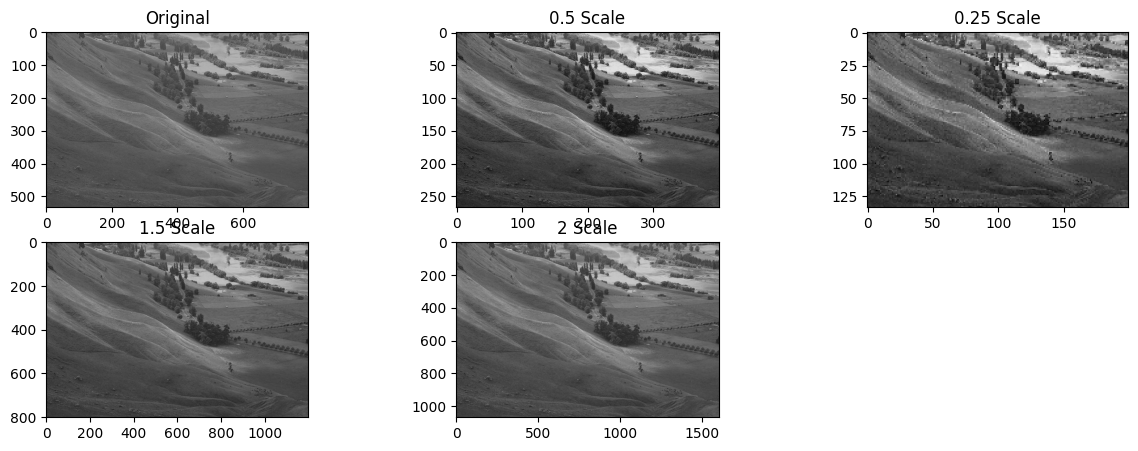

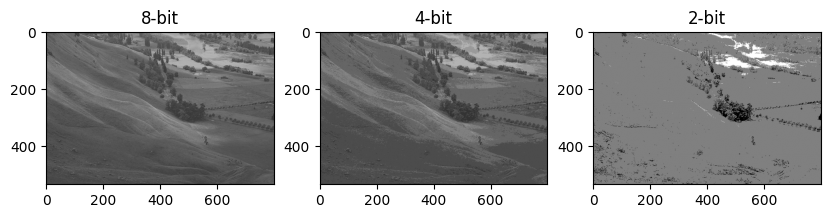

In [6]:

plt.figure(figsize=(15,5))

img_05 = cv2.resize(gray, (0,0), fx=0.5, fy=0.5)
img_025 = cv2.resize(gray, (0,0), fx=0.25, fy=0.25)
img_15 = cv2.resize(gray, (0,0), fx=1.5, fy=1.5)
img_2 = cv2.resize(gray, (0,0), fx=2, fy=2)

plt.subplot(2,3,1); plt.imshow(gray, cmap='gray');    plt.title('Original')
plt.subplot(2,3,2); plt.imshow(img_05, cmap='gray');  plt.title('0.5 Scale')
plt.subplot(2,3,3); plt.imshow(img_025, cmap='gray'); plt.title('0.25 Scale')
plt.subplot(2,3,4); plt.imshow(img_15, cmap='gray');  plt.title('1.5 Scale')
plt.subplot(2,3,5); plt.imshow(img_2, cmap='gray');   plt.title('2 Scale')
plt.show()

img_8bit = gray
img_4bit = (gray & 0xF0)
img_2bit = (gray & 0xC0)

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(img_8bit, cmap='gray'); plt.title('8-bit')
plt.subplot(1,3,2); plt.imshow(img_4bit, cmap='gray'); plt.title('4-bit')
plt.subplot(1,3,3); plt.imshow(img_2bit, cmap='gray'); plt.title('2-bit')
plt.show()

**Task 03**

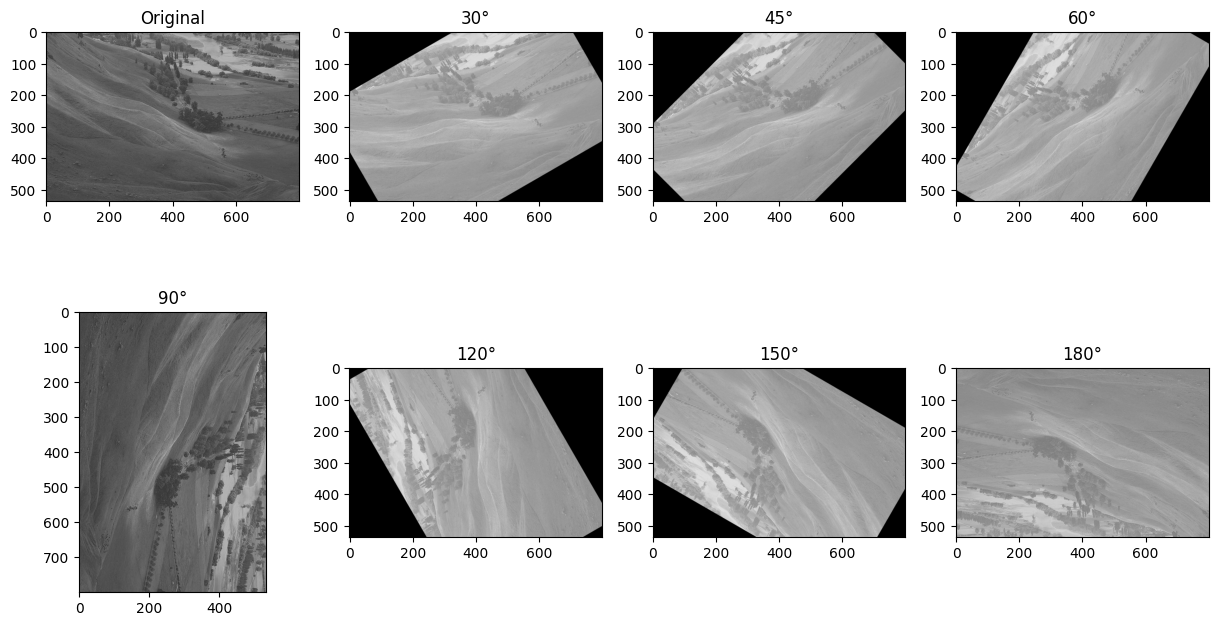

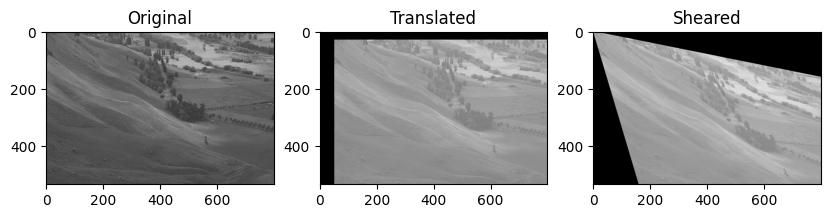

In [7]:
from scipy.ndimage import affine_transform

# Rotations
angles = [30, 45, 60, 90, 120, 150, 180]

plt.figure(figsize=(15,8))
plt.subplot(2,4,1)
plt.imshow(gray, cmap='gray')
plt.title('Original')

for i, angle in enumerate(angles):
    rotated = cv2.rotate(gray, cv2.ROTATE_90_CLOCKWISE) if angle==90 else cv2.warpAffine(gray, cv2.getRotationMatrix2D((gray.shape[1]//2, gray.shape[0]//2), angle, 1), (gray.shape[1], gray.shape[0]))
    plt.subplot(2,4,i+2)
    plt.imshow(rotated, cmap='gray')
    plt.title(f'{angle}°')

plt.show()

# Translation
M = np.float32([[1,0,50],[0,1,30]])
translated = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]))

# Shearing
M_shear = np.float32([[1, 0.3, 0],[0.2, 1, 0]])
sheared = cv2.warpAffine(gray, M_shear, (gray.shape[1], gray.shape[0]))

plt.figure(figsize=(10,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray');       plt.title('Original')
plt.subplot(1,3,2); plt.imshow(translated, cmap='gray'); plt.title('Translated')
plt.subplot(1,3,3); plt.imshow(sheared, cmap='gray');    plt.title('Sheared')
plt.show()

**Task:04**

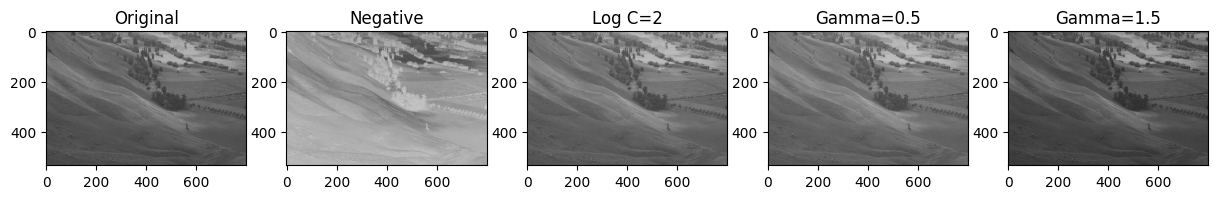

In [8]:
img_double = gray / 255.0

# Negative
negative = 255 - gray

# Log Transformation
c = 2
log_img = c * np.log1p(img_double)
log_img = log_img / log_img.max()

# Gamma Transformations
gamma1 = 0.5
gamma_bright = np.power(img_double, gamma1)

gamma2 = 1.5
gamma_dark = np.power(img_double, gamma2)

plt.figure(figsize=(15,4))
plt.subplot(1,5,1); plt.imshow(gray, cmap='gray');         plt.title('Original')
plt.subplot(1,5,2); plt.imshow(negative, cmap='gray');     plt.title('Negative')
plt.subplot(1,5,3); plt.imshow(log_img, cmap='gray');      plt.title('Log C=2')
plt.subplot(1,5,4); plt.imshow(gamma_bright, cmap='gray'); plt.title('Gamma=0.5')
plt.subplot(1,5,5); plt.imshow(gamma_dark, cmap='gray');   plt.title('Gamma=1.5')
plt.show()

**TASK:05**

/tmp/ipykernel_3088/1764877143.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,3,5); plt.hist(eq_manual.ravel(), 256, [0,256]);    plt.title('Manual Hist')
/tmp/ipykernel_3088/1764877143.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2,3,6); plt.hist(eq_histeq.ravel(), 256, [0,256]);    plt.title('equalizeHist() Hist')


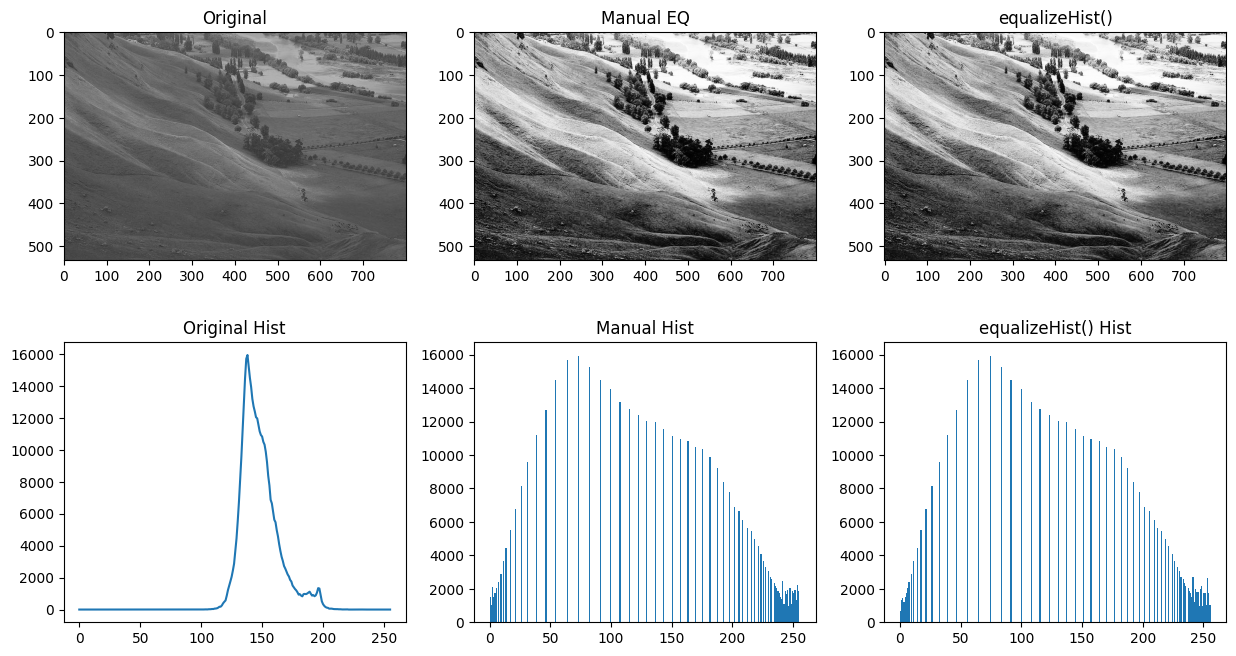

In [9]:
hist_orig = cv2.calcHist([gray], [0], None, [256], [0,256])

pdf = hist_orig / hist_orig.sum()
cdf = np.cumsum(pdf)
L = 256
new_values = np.uint8((L-1) * cdf)
eq_manual = new_values[gray]

eq_histeq = cv2.equalizeHist(gray)

plt.figure(figsize=(15,8))
plt.subplot(2,3,1); plt.imshow(gray, cmap='gray');      plt.title('Original')
plt.subplot(2,3,2); plt.imshow(eq_manual, cmap='gray'); plt.title('Manual EQ')
plt.subplot(2,3,3); plt.imshow(eq_histeq, cmap='gray'); plt.title('equalizeHist()')

plt.subplot(2,3,4); plt.plot(hist_orig);                          plt.title('Original Hist')
plt.subplot(2,3,5); plt.hist(eq_manual.ravel(), 256, [0,256]);    plt.title('Manual Hist')
plt.subplot(2,3,6); plt.hist(eq_histeq.ravel(), 256, [0,256]);    plt.title('equalizeHist() Hist')
plt.show()

**TASK:06**

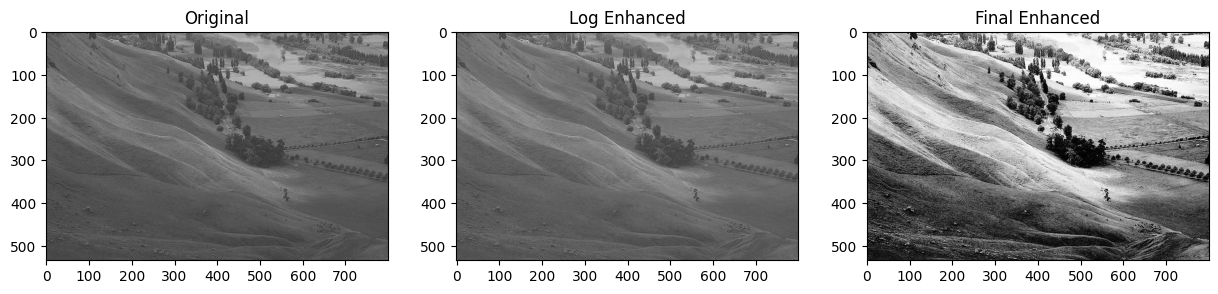

/tmp/ipykernel_3088/1361666152.py:22: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(1,3,1); plt.hist(gray.ravel(), 256, [0,256]);           plt.title('Original Hist')
/tmp/ipykernel_3088/1361666152.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(1,3,2); plt.hist(log_uint8.ravel(), 256, [0,256]);      plt.title('Log Hist')
/tmp/ipykernel_3088/1361666152.py:24: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(1,3,3); plt.hist(enhanced_image.ravel(), 256, [0,256]); plt.title('Final Hist')


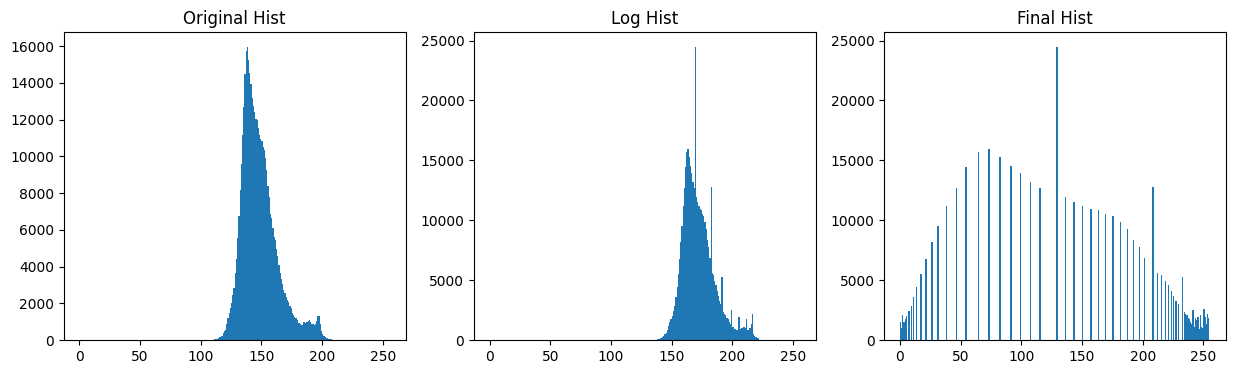

In [10]:
img_double = gray / 255.0

c = 2
log_img = c * np.log1p(img_double)
log_img = log_img / log_img.max()
log_uint8 = np.uint8(log_img * 255)

hist = cv2.calcHist([log_uint8], [0], None, [256], [0,256])
pdf = hist / hist.sum()
cdf = np.cumsum(pdf)
L = 256
new_values = np.uint8((L-1) * cdf)
enhanced_image = new_values[log_uint8]

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray');           plt.title('Original')
plt.subplot(1,3,2); plt.imshow(log_uint8, cmap='gray');      plt.title('Log Enhanced')
plt.subplot(1,3,3); plt.imshow(enhanced_image, cmap='gray'); plt.title('Final Enhanced')
plt.show()

plt.figure(figsize=(15,4))
plt.subplot(1,3,1); plt.hist(gray.ravel(), 256, [0,256]);           plt.title('Original Hist')
plt.subplot(1,3,2); plt.hist(log_uint8.ravel(), 256, [0,256]);      plt.title('Log Hist')
plt.subplot(1,3,3); plt.hist(enhanced_image.ravel(), 256, [0,256]); plt.title('Final Hist')
plt.show()

**bold text**